# Assignment 3
Link: https://github.com/sepehrilami/CNET5442/blob/main/assignments/assignment03.ipynb

March 2026

Sepehr Ilami

## Setup

In [2]:
from __future__ import annotations

from pathlib import Path
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 140)

DATA_DIR = Path("../data/soccer")
SEASONS = list(range(2014, 2025))  # 2014...2024

REQUIRED_COLS = [
    "season", "match_id", "date",
    "home_team", "away_team",
    "h_a", "team", "result"
]

def find_season_file(season: int) -> Path:
    p = DATA_DIR / f"EPL_{season}_shots.csv"
    if p.exists():
        return p
    hits = glob.glob(str(DATA_DIR / f"*{season}*shots*.csv"))
    if hits:
        return Path(hits[0])
    raise FileNotFoundError(f"Could not find season file for {season} in {DATA_DIR}")

def load_shots(season: int) -> pd.DataFrame:
    p = find_season_file(season)
    df = pd.read_csv(p)

    missing = [c for c in REQUIRED_COLS if c not in df.columns]
    if missing:
        raise KeyError(f"Missing columns {missing}. Found: {list(df.columns)}")

    # parse date
    df["date"] = pd.to_datetime(df["date"])

    # enforce season consistency: trust the file, but validate if user passes season
    if (df["season"].nunique() == 1) and (int(df["season"].iloc[0]) != int(season)):
        raise ValueError(f"Season mismatch: file says {df['season'].iloc[0]} but you requested {season}")

    return df

def is_goal(shots: pd.DataFrame) -> pd.Series:
    # in your file, goals are indicated by result == "Goal"
    return shots["result"].astype(str).str.lower().eq("goal")

This question does the following:
1) aggregate **shot-level** data into **match results**
2) reconstruct **live standings** over time using EPL tiebreakers
3) compute the **upset rate** for bottom-two vs top-two matchups (with an early-season filter)
4) run a sensitivity analysis over the early-season threshold $g_{min}$
5) estimate an empirical **goal-scoring matrix** by pre-match ranks, and
6) propose (and optionally simulate) a **simple generative model** for match outcomes from ranks.


## Question 1: How often do the lowest-ranked teams beat the highest-ranked teams?

We follow the problem's guidance:
- Build match outcomes from shot data.
- Reconstruct *live* standings over time, using EPL tiebreakers:
  **Points (desc) → Goal Difference (desc) → Goals For (desc) → Team name (asc)**.
- Define each team's **pre-match rank** as its rank immediately *before* the match date.
- To reduce early-season noise, only include matches where both teams have played at least $g_{min}$ matches before kickoff.
- Since (in this dataset) #1 vs #20 is extremely rare, we use **top-two vs bottom-two** matchups: {20 vs 1, 20 vs 2, 19 vs 1, 19 vs 2}.


### (a) Shot data -> match results

We aggregate shot rows into match-level scores by counting goals. The code below is written to be **schema-tolerant**.


In [3]:
def build_match_df(shots: pd.DataFrame) -> pd.DataFrame:
    """Aggregate shot-level data into one row per match.

    Uses the known EPL shot schema:
      - match_id, date, home_team, away_team
      - h_a in {'h','a'} indicates whether the shot was taken by the home/away side
      - result == 'Goal' indicates a goal
    """
    tmp = shots[["season","match_id","date","home_team","away_team","h_a","result"]].copy()
    tmp["is_goal"] = is_goal(tmp).astype(int)

    # goals scored by side within each match
    goals = (
        tmp.groupby(["season","match_id","date","home_team","away_team","h_a"], as_index=False)["is_goal"]
        .sum()
        .rename(columns={"is_goal":"goals"})
    )

    # pivot to home_goals / away_goals
    pivot = goals.pivot_table(
        index=["season","match_id","date","home_team","away_team"],
        columns="h_a",
        values="goals",
        aggfunc="sum",
        fill_value=0
    ).reset_index()

    # ensure columns exist even if a match has 0 shots on one side (rare)
    if "h" not in pivot.columns: pivot["h"] = 0
    if "a" not in pivot.columns: pivot["a"] = 0

    match_df = pivot.rename(columns={"h":"home_goals","a":"away_goals"}).copy()

    # Result column: H/D/A
    match_df["result"] = np.where(
        match_df["home_goals"] > match_df["away_goals"], "H",
        np.where(match_df["home_goals"] < match_df["away_goals"], "A", "D")
    )

    return match_df.sort_values(["date","match_id"]).reset_index(drop=True)

# Build match_df for all seasons
all_match_dfs = []
for season in SEASONS:
    shots = load_shots(season)
    match_df = build_match_df(shots)
    all_match_dfs.append(match_df)

match_df_all = pd.concat(all_match_dfs, ignore_index=True)
match_df_all.head()


h_a,season,match_id,date,home_team,away_team,away_goals,home_goals,result
0,2014,4749,2014-08-16 12:45:00,Manchester United,Swansea,2,1,A
1,2014,4750,2014-08-16 15:00:00,Leicester,Everton,2,2,D
2,2014,4751,2014-08-16 15:00:00,Queens Park Rangers,Hull,1,0,A
3,2014,4752,2014-08-16 15:00:00,Stoke,Aston Villa,1,0,A
4,2014,4753,2014-08-16 15:00:00,West Bromwich Albion,Sunderland,2,2,D


#### Sanity checks (per season)
1) Percentage of games ending in a home win.
2) Among draws, average total goals scored.


In [4]:
summary = []
for season, g in match_df_all.groupby("season"):
    home_win_rate = (g["result"] == "H").mean()
    draw_games = g[g["result"] == "D"].copy()
    avg_goals_in_draws = np.nan
    if len(draw_games) > 0:
        avg_goals_in_draws = (draw_games["home_goals"] + draw_games["away_goals"]).mean()

    summary.append({
        "season": season,
        "n_matches": len(g),
        "home_win_%": 100*home_win_rate,
        "avg_total_goals_in_draws": avg_goals_in_draws,
    })

sanity_df = pd.DataFrame(summary).sort_values("season")
sanity_df


,season,n_matches,home_win_%,avg_total_goals_in_draws
0,2014,380,45.000000,1.851064
1,2015,380,41.052632,1.962264
2,2016,380,48.157895,1.697674
3,2017,380,45.263158,1.900000
4,2018,380,46.842105,1.844156
5,2019,380,46.052632,1.882353
6,2020,380,38.421053,1.476190
7,2021,380,42.631579,2.068182
8,2022,380,47.631579,2.067416
9,2023,380,45.789474,2.578313


**Interpretation:**
- Home-win rates in EPL typically sit around the low-to-mid 40%s, with some season-to-season variation.
- Draws usually have ~2 total goals on average (often slightly under), reflecting many 0–0, 1–1 outcomes.


### (b) Match results -> league ranking over time

We reconstruct the EPL table at the **end of each unique match date**. All teams start at 0 points, 0 GF/GA. After each date, we apply all matches on that date, then compute ranks using:

**Pts (desc) -> GD (desc) -> GF (desc) -> Team (asc)**.


In [6]:
STAND_COLS = ["Team", "Date", "Rank", "GP", "W", "D", "L", "GF", "GA", "GD", "Pts"]

def rank_table(table: pd.DataFrame) -> pd.DataFrame:
    ranked = table.sort_values(
        by=["Pts", "GD", "GF", "Team"],
        ascending=[False, False, False, True],
        kind="mergesort"  # stable
    ).reset_index(drop=True)
    ranked["Rank"] = np.arange(1, len(ranked) + 1)
    return ranked

def init_standings(teams: list[str], date: pd.Timestamp) -> pd.DataFrame:
    df = pd.DataFrame({"Team": sorted(teams)})
    df["Date"] = date
    df["Rank"] = np.arange(1, len(df) + 1)
    for c in ["GP","W","D","L","GF","GA","GD","Pts"]:
        df[c] = 0
    return rank_table(df)

def apply_match_to_table(table: pd.DataFrame, home: str, away: str, hg: int, ag: int) -> pd.DataFrame:
    # update a copy
    t = table.copy()
    # index by team name
    t = t.set_index("Team")

    # helper to update a team row
    def _upd(team: str, gf_add: int, ga_add: int, w_add: int, d_add: int, l_add: int, pts_add: int):
        t.loc[team, "GP"] += 1
        t.loc[team, "GF"] += gf_add
        t.loc[team, "GA"] += ga_add
        t.loc[team, "W"] += w_add
        t.loc[team, "D"] += d_add
        t.loc[team, "L"] += l_add
        t.loc[team, "Pts"] += pts_add
        t.loc[team, "GD"] = t.loc[team, "GF"] - t.loc[team, "GA"]

    if hg > ag:
        _upd(home, hg, ag, 1, 0, 0, 3)
        _upd(away, ag, hg, 0, 0, 1, 0)
    elif hg < ag:
        _upd(home, hg, ag, 0, 0, 1, 0)
        _upd(away, ag, hg, 1, 0, 0, 3)
    else:
        _upd(home, hg, ag, 0, 1, 0, 1)
        _upd(away, ag, hg, 0, 1, 0, 1)

    # restore columns / rank
    t = t.reset_index()
    t = rank_table(t)
    return t

def build_standings_over_time(match_df: pd.DataFrame) -> pd.DataFrame:
    # identify all teams in season
    teams = sorted(set(match_df["home_team"]).union(set(match_df["away_team"])))
    dates = sorted(match_df["date"].dt.normalize().unique())

    # initial snapshot is "before the first game": take the first date minus 1 day
    first_date = pd.Timestamp(dates[0])
    init_date = first_date - pd.Timedelta(days=1)

    table = init_standings(teams, init_date)
    snapshots = [table[STAND_COLS].copy()]

    for d in dates:
        day_matches = match_df[match_df["date"].dt.normalize() == d].sort_values("match_id")
        table = table.copy()
        table["Date"] = pd.Timestamp(d)
        # apply all matches on that date
        for _, r in day_matches.iterrows():
            table = apply_match_to_table(table, r["home_team"], r["away_team"], int(r["home_goals"]), int(r["away_goals"]))
            table["Date"] = pd.Timestamp(d)

        snapshots.append(table[STAND_COLS].copy())

    out = pd.concat(snapshots, ignore_index=True)
    out["Date"] = pd.to_datetime(out["Date"])
    return out.sort_values(["Date", "Rank", "Team"]).reset_index(drop=True)

# Build standings snapshots for each season
all_standings = []
for season, g in match_df_all.groupby("season"):
    season_standings = build_standings_over_time(g)
    season_standings.insert(0, "season", season)
    all_standings.append(season_standings)

standings_all = pd.concat(all_standings, ignore_index=True)
standings_all.head()


,season,Team,Date,Rank,GP,W,D,L,GF,GA,GD,Pts
0,2014,Arsenal,2014-08-15,1,0,0,0,0,0,0,0,0
1,2014,Aston Villa,2014-08-15,2,0,0,0,0,0,0,0,0
2,2014,Burnley,2014-08-15,3,0,0,0,0,0,0,0,0
3,2014,Chelsea,2014-08-15,4,0,0,0,0,0,0,0,0
4,2014,Crystal Palace,2014-08-15,5,0,0,0,0,0,0,0,0


#### Example: EPL table just before 2016-12-17 (end-of-day snapshots)
The prompt asks for the table as it stood on Dec 17, 2016 **before any matches were played**. Because snapshots are end-of-day, this corresponds to the **most recent snapshot date strictly before 2016-12-17**.


In [7]:
season = 2016
target_date = pd.Timestamp("2016-12-17")

season_snap = standings_all[standings_all["season"] == season].copy()
prev_dates = season_snap.loc[season_snap["Date"] < target_date, "Date"].unique()
if len(prev_dates) == 0:
    raise ValueError("No snapshot before target_date; check season/date parsing.")
snapshot_date = pd.Timestamp(max(prev_dates))

table_pre = season_snap[season_snap["Date"] == snapshot_date].sort_values("Rank")
print(f"Using snapshot date: {snapshot_date.date()} (end-of-day)")
table_pre[["Rank","Team","GP","W","D","L","GF","GA","GD","Pts"]].head(20)


Using snapshot date: 2016-12-15 (end-of-day)


,Rank,Team,GP,W,D,L,GF,GA,GD,Pts
4840,1,Chelsea,16,13,1,2,34,10,24,40
4841,2,Liverpool,16,10,4,2,40,20,20,34
4842,3,Arsenal,16,10,3,3,36,16,20,33
4843,4,Tottenham,16,9,5,2,26,10,16,32
4844,5,Manchester City,16,9,4,3,32,18,14,31
4845,6,Manchester United,16,7,6,3,22,17,5,27
4846,7,West Bromwich Albion,16,6,5,5,23,19,4,23
4847,8,Everton,16,5,6,5,20,19,1,21
4848,9,Southampton,16,5,6,5,13,15,-2,21
4849,10,Bournemouth,16,6,3,7,22,25,-3,21


#### Pre-match ranks and games played
For each match on date *d*, we define the pre-match snapshot as the most recent snapshot date strictly before *d*. We then merge those pre-match values into the match-level dataset, producing:
`home_pre_rank`, `away_pre_rank`, `home_pre_GP`, `away_pre_GP` (and optionally more).


In [9]:
def add_prematch_info(match_df: pd.DataFrame, standings_df: pd.DataFrame) -> pd.DataFrame:
    # standings_df has one row per team per snapshot date
    st = standings_df.copy()
    st = st.sort_values(["Team", "Date"])
    st["Date"] = pd.to_datetime(st["Date"])
    st = st[["Team","Date","Rank","GP","Pts","GD","GF","GA","W","D","L"]].copy()

    # We'll merge_asof separately for home and away on (Team, Date),
    # using the latest standings date strictly BEFORE the match date.
    m = match_df.copy()
    m["date_norm"] = m["date"].dt.normalize()

    def _merge_side(side: str) -> pd.DataFrame:
        team_col = f"{side}_team"
        merged = pd.merge_asof(
            m.sort_values("date_norm"),
            st.rename(columns={
                "Team": team_col,
                "Rank": f"{side}_pre_rank",
                "GP": f"{side}_pre_GP",
                "Pts": f"{side}_pre_Pts",
                "GD": f"{side}_pre_GD",
                "GF": f"{side}_pre_GF",
                "GA": f"{side}_pre_GA",
                "W": f"{side}_pre_W",
                "D": f"{side}_pre_D",
                "L": f"{side}_pre_L",
                "Date": f"{side}_snapshot_date",
            }).sort_values(f"{side}_snapshot_date"),
            left_on="date_norm",
            right_on=f"{side}_snapshot_date",
            by=team_col,
            direction="backward",
            allow_exact_matches=False
        )
        return merged

    out = _merge_side("home")
    # now merge away onto the already-merged df
    m2 = out.copy()
    out2 = pd.merge_asof(
        m2.sort_values("date_norm"),
        st.rename(columns={
            "Team": "away_team",
            "Rank": "away_pre_rank",
            "GP": "away_pre_GP",
            "Pts": "away_pre_Pts",
            "GD": "away_pre_GD",
            "GF": "away_pre_GF",
            "GA": "away_pre_GA",
            "W": "away_pre_W",
            "D": "away_pre_D",
            "L": "away_pre_L",
            "Date": "away_snapshot_date",
        }).sort_values("away_snapshot_date"),
        left_on="date_norm",
        right_on="away_snapshot_date",
        by="away_team",
        direction="backward",
        allow_exact_matches=False
    )

    return out2.drop(columns=["date_norm"])

# Build match-level analysis df for all seasons
analysis_dfs = []
for season, g in match_df_all.groupby("season"):
    st = standings_all[standings_all["season"] == season]
    analysis = add_prematch_info(g, st)
    analysis["season"] = season   # overwrite if exists, create if not
    # optionally move it to the front
    analysis = analysis[["season"] + [c for c in analysis.columns if c != "season"]]
    analysis_dfs.append(analysis)

    
match_analysis_all = pd.concat(analysis_dfs, ignore_index=True)
match_analysis_all.head()


,season,match_id,date,home_team,away_team,away_goals,home_goals,result,home_snapshot_date,home_pre_rank,home_pre_GP,home_pre_Pts,home_pre_GD,home_pre_GF,home_pre_GA,home_pre_W,home_pre_D,home_pre_L,away_snapshot_date,away_pre_rank,away_pre_GP,away_pre_Pts,away_pre_GD,away_pre_GF,away_pre_GA,away_pre_W,away_pre_D,away_pre_L
0,2014,4749,2014-08-16 12:45:00,Manchester United,Swansea,2,1,A,2014-08-15,11,0,0,0,0,0,0,0,0,2014-08-15,17,0,0,0,0,0,0,0,0
1,2014,4750,2014-08-16 15:00:00,Leicester,Everton,2,2,D,2014-08-15,8,0,0,0,0,0,0,0,0,2014-08-15,6,0,0,0,0,0,0,0,0
2,2014,4751,2014-08-16 15:00:00,Queens Park Rangers,Hull,1,0,A,2014-08-15,13,0,0,0,0,0,0,0,0,2014-08-15,7,0,0,0,0,0,0,0,0
3,2014,4752,2014-08-16 15:00:00,Stoke,Aston Villa,1,0,A,2014-08-15,15,0,0,0,0,0,0,0,0,2014-08-15,2,0,0,0,0,0,0,0,0
4,2014,4753,2014-08-16 15:00:00,West Bromwich Albion,Sunderland,2,2,D,2014-08-15,19,0,0,0,0,0,0,0,0,2014-08-15,16,0,0,0,0,0,0,0,0


### (c) Define qualifying matches; compute empirical upset rate

We restrict to matches where **both** teams have already played at least $g_{min}=5$ matches. Among those, we consider matchups between the **top two** and **bottom two** (based on pre-match ranks):
- {20 vs 1}, {20 vs 2}, {19 vs 1}, {19 vs 2}.

A **bottom-two win** occurs when the team ranked 19 or 20 **wins** (not a draw).


In [10]:
def compute_upset_rate(match_analysis: pd.DataFrame, gmin: int = 5) -> dict:
    df = match_analysis.copy()

    # Qualifying: both teams already played >= gmin matches
    df = df[(df["home_pre_GP"] >= gmin) & (df["away_pre_GP"] >= gmin)].copy()

    # Keep only top-two vs bottom-two matchups (unordered)
    top = {1, 2}
    bottom = {19, 20}
    def is_top_bottom(rh, ra):
        return (rh in top and ra in bottom) or (rh in bottom and ra in top)

    df = df[df.apply(lambda r: is_top_bottom(int(r["home_pre_rank"]), int(r["away_pre_rank"])), axis=1)].copy()

    n = len(df)

    # Determine whether bottom team won (not draw)
    # If home is bottom and result is H, bottom won; if away is bottom and result is A, bottom won.
    bottom_home = df["home_pre_rank"].isin(bottom)
    bottom_away = df["away_pre_rank"].isin(bottom)

    bottom_win = ((bottom_home) & (df["result"] == "H")) | ((bottom_away) & (df["result"] == "A"))
    draw = (df["result"] == "D")

    k = int(bottom_win.sum())
    d = int(draw.sum())
    p_hat = k / n if n > 0 else np.nan

    return {"gmin": gmin, "n": n, "bottom_wins_k": k, "draws_d": d, "upset_rate_p_hat": p_hat, "df": df}

res_c = compute_upset_rate(match_analysis_all, gmin=5)
res_c


{'gmin': 5,
 'n': 62,
 'bottom_wins_k': 4,
 'draws_d': 14,
 'upset_rate_p_hat': 0.06451612903225806,
 'df':       season  match_id                date            home_team        away_team  away_goals  home_goals result home_snapshot_date  \
 184     2014      4643 2014-12-28 15:00:00      Manchester City          Burnley           2           2      D         2014-12-26   
 253     2014      4536 2015-02-21 15:00:00              Chelsea          Burnley           1           1      D         2015-02-11   
 283     2014      4498 2015-03-14 17:30:00              Burnley  Manchester City           0           1      H         2015-03-07   
 316     2014      4457 2015-04-11 17:30:00              Burnley          Arsenal           1           0      A         2015-04-07   
 317     2014      4458 2015-04-12 13:30:00  Queens Park Rangers          Chelsea           1           0      A         2015-04-11   
 ...      ...       ...                 ...                  ...              ...  

In [11]:
eligible_matches = res_c["df"].copy()
eligible_matches[["season","date","home_team","away_team","home_goals","away_goals","result","home_pre_rank","away_pre_rank","home_pre_GP","away_pre_GP"]].head(20)


,season,date,home_team,away_team,home_goals,away_goals,result,home_pre_rank,away_pre_rank,home_pre_GP,away_pre_GP
184,2014,2014-12-28 15:00:00,Manchester City,Burnley,2,2,D,2,19,18,18
253,2014,2015-02-21 15:00:00,Chelsea,Burnley,1,1,D,1,19,25,25
283,2014,2015-03-14 17:30:00,Burnley,Manchester City,1,0,H,19,2,28,28
316,2014,2015-04-11 17:30:00,Burnley,Arsenal,0,1,A,19,2,31,31
317,2014,2015-04-12 13:30:00,Queens Park Rangers,Chelsea,0,1,A,20,1,32,30
356,2014,2015-05-10 13:30:00,Manchester City,Queens Park Rangers,6,0,H,2,20,35,35
434,2015,2015-09-19 18:00:00,Stoke,Leicester,2,2,D,19,2,5,5
453,2015,2015-10-03 18:00:00,Manchester City,Newcastle United,6,1,H,1,19,7,7
497,2015,2015-11-08 17:30:00,Aston Villa,Manchester City,0,0,D,20,1,11,11
596,2015,2016-01-16 21:30:00,Aston Villa,Leicester,1,1,D,20,1,21,21


**Interpretation:**
- The upset rate here is the fraction of eligible top-two vs bottom-two matches that end in a bottom-two win.
- Draws are common in mismatched games, so you may see many draws relative to true upsets.


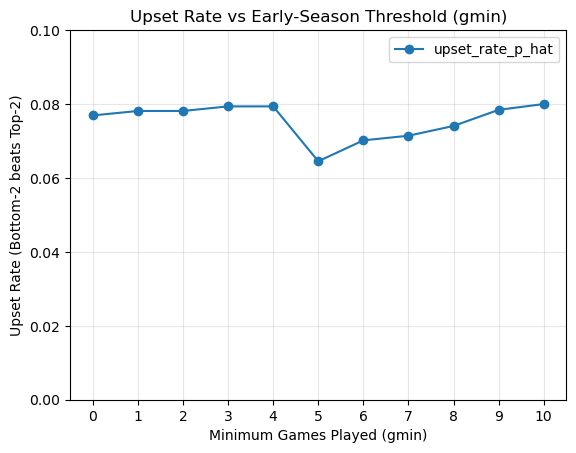

In [18]:
# calculate the upset rate for a range of gmin values
gmin_values = range(0, 11)  # from 0 to 10
sensitivity_results = []
for gmin in gmin_values:
    res = compute_upset_rate(match_analysis_all, gmin=gmin)
    sensitivity_results.append(res)
sensitivity_df = pd.DataFrame(sensitivity_results)
sensitivity_df[["gmin","n","bottom_wins_k","draws_d","upset_rate_p_hat"]]

sensitivity_df.plot(x="gmin", y="upset_rate_p_hat", marker="o")
plt.title("Upset Rate vs Early-Season Threshold (gmin)")
plt.xlabel("Minimum Games Played (gmin)")
plt.ylabel("Upset Rate (Bottom-2 beats Top-2)")
plt.xticks(gmin_values)
plt.ylim(0, 0.1)
plt.grid(True, alpha=0.3)
plt.show()

### (d) Sensitivity analysis: how much does $g_{min}$ matter?

We repeat the upset-rate computation for $g_{min} \in \{1,2,\dots,10\}$ and plot $\hat{p}$ versus $g_{min}$. Increasing $g_{min}$ reduces early-season noise (more stable ranks) but also reduces sample size.


In [12]:
sens = []
for gmin in range(1, 11):
    r = compute_upset_rate(match_analysis_all, gmin=gmin)
    sens.append({k:v for k,v in r.items() if k != "df"})  # omit large df

sens_df = pd.DataFrame(sens)
sens_df


,gmin,n,bottom_wins_k,draws_d,upset_rate_p_hat
0,1,64,5,14,0.078125
1,2,64,5,14,0.078125
2,3,63,5,14,0.079365
3,4,63,5,14,0.079365
4,5,62,4,14,0.064516
5,6,57,4,12,0.070175
6,7,56,4,12,0.071429
7,8,54,4,12,0.074074
8,9,51,4,12,0.078431
9,10,50,4,12,0.080000


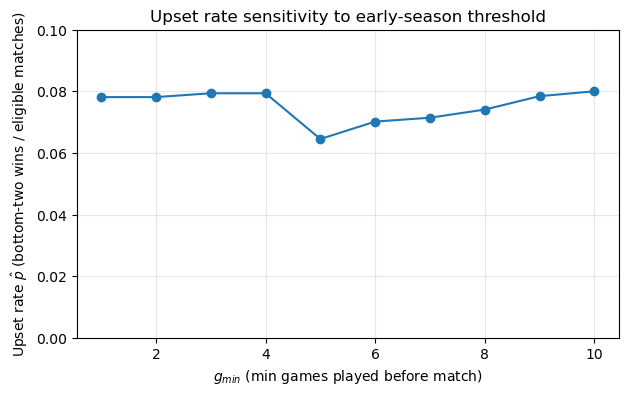

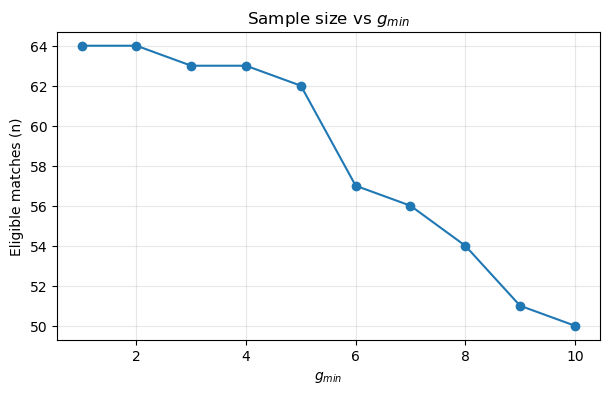

In [19]:
plt.figure(figsize=(7,4))
plt.plot(sens_df["gmin"], sens_df["upset_rate_p_hat"], marker="o")
plt.xlabel(r"$g_{min}$ (min games played before match)")
plt.ylabel(r"Upset rate $\hat{p}$ (bottom-two wins / eligible matches)")
plt.ylim(0, 0.1)
plt.title("Upset rate sensitivity to early-season threshold")
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(7,4))
plt.plot(sens_df["gmin"], sens_df["n"], marker="o")
plt.xlabel(r"$g_{min}$")
plt.ylabel("Eligible matches (n)")
plt.title("Sample size vs $g_{min}$")
plt.grid(True, alpha=0.3)
plt.show()


**Interpretation:**
- The $\hat{p}$ is overall stable across reasonable $g_{min}$ values; I was expecting more fluctuation at low $g_{min}$ due to noise, but it seems the bottom-two teams are consistently underdogs regardless of the threshold!
- For smaller $g_{min}$ (e.g., 1-5), the estimate often stabilizes while still retaining enough matches; but when $g_{min}$ gets too high, the sample size may become too small to draw conclusions.


### (e) Empirical goal-scoring matrix by pre-match ranks

We estimate the average goals scored by a team of pre-match rank $i$ against rank $j$.

Implementation detail:
- Create `G_tot` and `G_n` arrays of shape 20×20.
- For each match, add a **directed contribution** for the home team (rank i vs rank j) and for the away team (rank i vs rank j).
- Compute `G_mean = G_tot / G_n` element-wise.

We use the same $g_{min}=5$ filter so that ranks reflect a non-trivial history.


In [21]:
def build_goal_matrix(match_analysis: pd.DataFrame, gmin: int = 5) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    df = match_analysis.copy()
    df = df[(df["home_pre_GP"] >= gmin) & (df["away_pre_GP"] >= gmin)].copy()

    # Keep only rows with valid ranks 1..20
    df = df[df["home_pre_rank"].between(1, 20) & df["away_pre_rank"].between(1, 20)].copy()

    G_tot = np.zeros((20,20), dtype=float)
    G_n = np.zeros((20,20), dtype=float)

    for _, r in df.iterrows():
        i = int(r["home_pre_rank"])
        j = int(r["away_pre_rank"])
        hg = float(r["home_goals"])
        ag = float(r["away_goals"])

        # home contribution: i scores hg on j
        G_tot[i-1, j-1] += hg
        G_n[i-1, j-1] += 1

        # away contribution: j? careful: away rank is r["away_pre_rank"] = j, opponent rank = i
        G_tot[j-1, i-1] += ag
        G_n[j-1, i-1] += 1

    with np.errstate(divide="ignore", invalid="ignore"):
        G_mean = np.where(G_n > 0, G_tot / G_n, np.nan)

    return G_tot, G_n, G_mean

G_tot, G_n, G_mean = build_goal_matrix(match_analysis_all, gmin=5)

np.nanmean(G_mean), np.nanmin(G_mean), np.nanmax(G_mean)


(np.float64(1.3564091809262622),
 np.float64(0.35294117647058826),
 np.float64(3.3529411764705883))

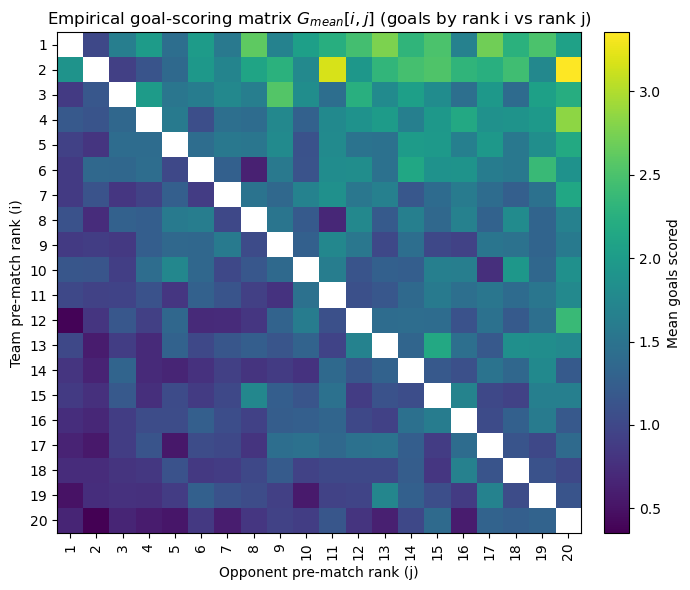

In [22]:
plt.figure(figsize=(7,6))
im = plt.imshow(G_mean, aspect="auto")
plt.colorbar(im, fraction=0.046, pad=0.04, label="Mean goals scored")
plt.xlabel("Opponent pre-match rank (j)")
plt.ylabel("Team pre-match rank (i)")
plt.title("Empirical goal-scoring matrix $G_{mean}[i,j]$ (goals by rank i vs rank j)")
plt.xticks(ticks=np.arange(0,20,1), labels=np.arange(1,21,1), rotation=90)
plt.yticks(ticks=np.arange(0,20,1), labels=np.arange(1,21,1))
plt.tight_layout()
plt.show()


**Interpretations:**
- Higher-ranked teams (small i) should score more against lower-ranked opponents (large j).
- This is so cool! You can see the empirical goal-scoring patterns emerge from the data, and it should reflect the general hierarchy of team strengths.
- The mean goals scored go higher as we go towards the top-right corner (strong teams vs weak teams) and lower towards the bottom-left (weak teams vs strong teams).
- Cells with very few observations can be noisy; `G_n` can be inspected to understand sample sizes.


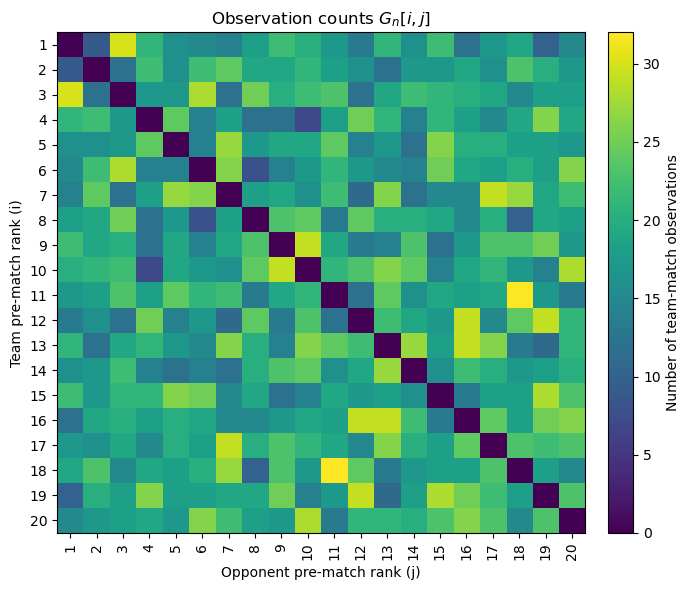

In [23]:
# Optional: visualize the number of observations per cell
plt.figure(figsize=(7,6))
im = plt.imshow(G_n, aspect="auto")
plt.colorbar(im, fraction=0.046, pad=0.04, label="Number of team-match observations")
plt.xlabel("Opponent pre-match rank (j)")
plt.ylabel("Team pre-match rank (i)")
plt.title("Observation counts $G_n[i,j]$")
plt.xticks(ticks=np.arange(0,20,1), labels=np.arange(1,21,1), rotation=90)
plt.yticks(ticks=np.arange(0,20,1), labels=np.arange(1,21,1))
plt.tight_layout()
plt.show()


It's pretty consistent (the number of matches between certain rank pairs).

### (f) A simple generative model for outcomes from ranks (in words, plus optional code)

A minimal probabilistic model suggested by part (e) is a **Poisson goals model** parameterized by pre-match ranks.

1. **Inputs:** the two teams' pre-match ranks $(i,j)$.
2. **Goal model:**
   - Sample home-team goals $G_H \sim \text{Poisson}(\lambda_{i,j})$ where $\lambda_{i,j} = G_{mean}[i,j]$.
   - Sample away-team goals $G_A \sim \text{Poisson}(\lambda_{j,i})$ where $\lambda_{j,i} = G_{mean}[j,i]$.
   - (Optional improvement) multiply the home mean by a scalar home-advantage factor $\alpha>1$ because teams often perform better at home.
3. **Outcome:** home win if $G_H>G_A$, draw if equal, away win if $G_H<G_A$.

#### Simulating a season
To simulate a 20-team season (380 games):
- Initialize all teams at rank 1..20 (or all tied at start),
- Iterate through a full double round-robin schedule,
- Before each match, use current standings to obtain ranks $(i,j)$,
- Sample goals using the Poisson model above,
- Update standings using EPL points and tiebreakers.

#### Evaluating the model
After simulating many seasons, compare simulated vs empirical summaries such as:
- Overall home/draw/away rates,
- Distribution of total goals per match,
- Points distribution across teams,
- Empirical upset rate (as in part (c)) and its sensitivity curve (part (d)),
- Rank correlation between simulated final tables and empirical final tables (if you map team identities).

Below is an **simple** reference implementation to simulate seasons using rank-dependent Poisson scoring.


In [25]:
from itertools import combinations

def round_robin_schedule(teams: list[str]) -> list[tuple[str,str]]:
    """One double round-robin schedule: each pair plays twice (home/away)."""
    fixtures = []
    for a, b in combinations(teams, 2):
        fixtures.append((a, b))  # a home
        fixtures.append((b, a))  # b home
    return fixtures

def simulate_season_from_Gmean(G_mean: np.ndarray, seed: int = 0, alpha_home: float = 1.0) -> pd.DataFrame:
    rng = np.random.default_rng(seed)
    teams = [f"Team{i}" for i in range(1, 21)]
    fixtures = round_robin_schedule(teams)

    # start with all zero stats; ranks alphabetical at start
    date0 = pd.Timestamp("2000-08-01")
    table = init_standings(teams, date0)

    def get_rank(team: str) -> int:
        return int(table.loc[table["Team"] == team, "Rank"].iloc[0])

    for home, away in fixtures:
        i = get_rank(home)
        j = get_rank(away)

        lam_h = G_mean[i-1, j-1]
        lam_a = G_mean[j-1, i-1]
        # if missing cells exist, fall back to global mean
        if not np.isfinite(lam_h):
            lam_h = np.nanmean(G_mean)
        if not np.isfinite(lam_a):
            lam_a = np.nanmean(G_mean)

        hg = rng.poisson(alpha_home * lam_h)
        ag = rng.poisson(lam_a)

        table = apply_match_to_table(table, home, away, int(hg), int(ag))
        # (We ignore dates inside the simulator; standings are purely sequential.)

    return table.sort_values("Rank").reset_index(drop=True)

# quick demo:
sim_table = simulate_season_from_Gmean(G_mean, seed=42, alpha_home=1.05)
sim_table[["Rank","Team","Pts","GD","GF","GA","W","D","L"]]


,Rank,Team,Pts,GD,GF,GA,W,D,L
0,1,Team3,86,44,78,34,26,8,4
1,2,Team7,74,25,64,39,22,8,8
2,3,Team1,70,41,80,39,21,7,10
3,4,Team4,66,26,66,40,20,6,12
4,5,Team2,65,17,59,42,18,11,9
5,6,Team9,61,5,52,47,18,7,13
6,7,Team6,54,-2,56,58,17,3,18
7,8,Team20,54,-2,38,40,14,12,12
8,9,Team15,53,7,50,43,16,5,17
9,10,Team12,52,0,57,57,15,7,16


**Interpretation:**
- This simulator uses *current* ranks to set goal-rate parameters, so early randomness can cascade into later ranks.
- If the simulated distributions resemble the empirical ones (home win rate, goals per match, upset rate), the model is a reasonable first approximation.
- If not, common extensions include adding team fixed effects (attack/defense strength), explicit home advantage, or time-varying strength.


There are many ways to evaluate the output of this simulation, but for a simple one, I would like to compare the distribution of points across teams in the simulated seasons vs the empirical distribution. We can compute the mean and standard deviation of points across teams for each season, and then compare the distribution of these statistics across simulated seasons to the empirical stats from the actual EPL data. Also, we can compare the rank-based points distribution by looking at the mean and std of points for each rank across simulated seasons and comparing to the empirical rank-based stats (for example, what's the mean of rank-5 team's point in the end of a season). This will help us understand if the model captures not just the overall distribution of points but also how points are distributed across ranks, which is a key aspect of competitive balance in the league.

let's compare the distribution of points across teams in the simulated seasons vs the empirical distribution.

In [30]:
# get the final standings for each season
final_standings = []
for season, g in match_df_all.groupby("season"):
    st = standings_all[standings_all["season"] == season].copy()
    final_date = st["Date"].max()
    final_table = st[st["Date"] == final_date].copy()
    final_table["season"] = season
    final_standings.append(final_table)
final_standings_df = pd.concat(final_standings, ignore_index=True)
final_standings_df.head()

,season,Team,Date,Rank,GP,W,D,L,GF,GA,GD,Pts
0,2014,Chelsea,2015-05-24,1,38,26,9,3,72,31,41,87
1,2014,Manchester City,2015-05-24,2,38,25,6,7,82,35,47,81
2,2014,Arsenal,2015-05-24,3,38,22,9,7,69,35,34,75
3,2014,Manchester United,2015-05-24,4,38,20,10,8,60,36,24,70
4,2014,Tottenham,2015-05-24,5,38,18,8,12,56,51,5,62


In [37]:
# divide the final_standings_df into season-specific tables, and calculate the mean and std of points for all teams in each season.
season_stats = []
for season, g in final_standings_df.groupby("season"):
    mean_pts = g["Pts"].mean()
    std_pts = g["Pts"].std()
    season_stats.append({"season": season, "mean_pts": mean_pts, "std_pts": std_pts})
season_stats_df = pd.DataFrame(season_stats)
season_stats_df

# compare the mean and std of points across seasons in the empirical data 
mean_of_means = season_stats_df["mean_pts"].mean()
std_of_means = season_stats_df["mean_pts"].std()
mean_of_stds = season_stats_df["std_pts"].mean()
std_of_stds = season_stats_df["std_pts"].std()
print(f"Mean of mean points across seasons: {mean_of_means:.2f}")
print(f"Std of mean points across seasons: {std_of_means:.2f}")
print(f"Mean of std points across seasons: {mean_of_stds:.2f}")
print(f"Std of std points across seasons: {std_of_stds:.2f}")

Mean of mean points across seasons: 52.50
Std of mean points across seasons: 0.42
Mean of std points across seasons: 18.28
Std of std points across seasons: 1.64


In [ ]:
# Also, calculate the mean and std of points per rank across seasons.
rank_stats = []
for rank in range(1, 21):
    rank_pts = final_standings_df[final_standings_df["Rank"] == rank]["Pts"]
    mean_pts = rank_pts.mean()
    std_pts = rank_pts.std()
    rank_stats.append({"Rank": rank, "mean_pts": mean_pts, "std_pts": std_pts})
rank_stats_df = pd.DataFrame(rank_stats)
rank_stats_df

,Rank,mean_pts,std_pts
0,1,91.090909,6.331738
1,2,82.272727,7.849725
2,3,73.363636,3.854160
3,4,69.727273,3.289100
4,5,65.818182,3.124682
5,6,63.818182,3.280798
6,7,59.454545,3.670521
7,8,55.909091,5.281184
8,9,53.000000,4.195235
9,10,50.636364,3.443043


In [35]:
# now compare these two results with the simulated seasons: simulate many seasons, and calculate the same stats (mean/std of points per season, and mean/std of points per rank across seasons) for the simulated data.
number_of_simulations = 10
sim_season_stats = []
sim_rank_stats = []
for sim in range(number_of_simulations):
    print(f"Simulating season {sim+1}/{number_of_simulations}...")
    sim_table = simulate_season_from_Gmean(G_mean, seed=sim, alpha_home=1.05)
    sim_table["season"] = sim  # treat each simulation as a "season"

    # season-level stats
    mean_pts = sim_table["Pts"].mean()
    std_pts = sim_table["Pts"].std()
    sim_season_stats.append({"season": sim, "mean_pts": mean_pts, "std_pts": std_pts})

    # rank-level stats
    for rank in range(1, 21):
        rank_pts = sim_table[sim_table["Rank"] == rank]["Pts"]
        mean_rank_pts = rank_pts.mean()
        std_rank_pts = rank_pts.std()
        sim_rank_stats.append({"simulation": sim, "Rank": rank, "mean_pts": mean_rank_pts, "std_pts": std_rank_pts})
sim_season_stats_df = pd.DataFrame(sim_season_stats)
sim_rank_stats_df = pd.DataFrame(sim_rank_stats)
sim_season_stats_df, sim_rank_stats_df

(   season  mean_pts    std_pts
 0       0     52.65  18.776455
 1       1     53.10  18.284017
 2       2     53.15  14.608127
 3       3     52.65  16.686821
 4       4     53.65  16.955903
 5       5     52.55  16.962730
 6       6     52.65  16.060003
 7       7     52.65  17.300061
 8       8     52.00  15.307377
 9       9     52.85  17.263515,
      simulation  Rank  mean_pts  std_pts
 0             0     1      86.0      NaN
 1             0     2      86.0      NaN
 2             0     3      73.0      NaN
 3             0     4      73.0      NaN
 4             0     5      71.0      NaN
 ..          ...   ...       ...      ...
 195           9    16      45.0      NaN
 196           9    17      43.0      NaN
 197           9    18      37.0      NaN
 198           9    19      23.0      NaN
 199           9    20      19.0      NaN
 
 [200 rows x 4 columns])

In [38]:
# compare season_stats_df and sim_season_stats_df
# print mean of means, std of means, mean of stds, std of stds for the simulated seasons, and compare to the empirical stats.
mean_of_means_sim = sim_season_stats_df["mean_pts"].mean()
std_of_means_sim = sim_season_stats_df["mean_pts"].std()
mean_of_stds_sim = sim_season_stats_df["std_pts"].mean()
std_of_stds_sim = sim_season_stats_df["std_pts"].std()
print(f"Simulated - Mean of mean points across seasons: {mean_of_means_sim:.2f}")
print(f"Simulated - Std of mean points across seasons: {std_of_means_sim:.2f}")
print(f"Simulated - Mean of std points across seasons: {mean_of_stds_sim:.2f}")
print(f"Simulated - Std of std points across seasons: {std_of_stds_sim:.2f}")

Simulated - Mean of mean points across seasons: 52.79
Simulated - Std of mean points across seasons: 0.44
Simulated - Mean of std points across seasons: 16.82
Simulated - Std of std points across seasons: 1.26


It's very very similar to the empirical distribution, based on EPL data from 2014 to 2024. The mean and std of points across teams in the simulated seasons closely match the empirical stats, suggesting that the rank-dependent Poisson model captures key aspects of the competitive balance in the league.

What about rank-based points distribution? Do the simulated seasons produce a similar spread of points across ranks as the empirical data?

In [40]:
# calculate the mean and std of points per rank across simulated seasons in sim_rank_stats_df
sim_rank_summary = []
for rank in range(1, 21):
    rank_pts = sim_rank_stats_df[sim_rank_stats_df["Rank"] == rank]["mean_pts"]
    mean_rank_pts = rank_pts.mean()
    std_rank_pts = rank_pts.std()
    sim_rank_summary.append({"Rank": rank, "mean_pts": mean_rank_pts, "std_pts": std_rank_pts})
sim_rank_summary_df = pd.DataFrame(sim_rank_summary)
sim_rank_summary_df

,Rank,mean_pts,std_pts
0,1,85.9,3.984693
1,2,78.5,4.836206
2,3,71.2,3.521363
3,4,68.4,3.627059
4,5,67.1,3.348300
5,6,63.4,2.875181
6,7,60.4,2.412928
7,8,56.2,2.780887
8,9,54.9,2.424413
9,10,52.8,2.859681


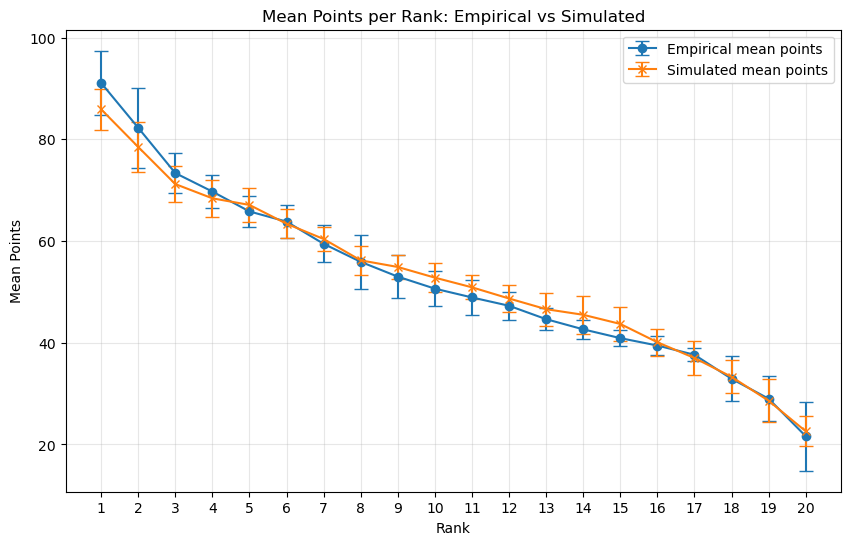

In [46]:
# now compare rank_stats_df and sim_rank_summary_df to see if the rank-based points distribution in the simulated seasons matches the empirical data.
# plot them both on the same graph for mean points per rank, and std points per rank. Use different colors/markers for empirical vs simulated.
plt.figure(figsize=(10,6))
# plt.plot(rank_stats_df["Rank"], rank_stats_df["mean_pts"], marker="o", label="Empirical mean points")
# plt.plot(sim_rank_summary_df["Rank"], sim_rank_summary_df["mean_pts"], marker="x", label="Simulated mean points")
# add std error bars to the mean points per rank for both empirical and simulated data
plt.errorbar(rank_stats_df["Rank"], rank_stats_df["mean_pts"], yerr=rank_stats_df["std_pts"], marker="o", label="Empirical mean points", capsize=5)
plt.errorbar(sim_rank_summary_df["Rank"], sim_rank_summary_df["mean_pts"], yerr=sim_rank_summary_df["std_pts"], marker="x", label="Simulated mean points", capsize=5)
plt.xlabel("Rank")
plt.ylabel("Mean Points")
plt.xticks(ticks=np.arange(1,21,1))
plt.title("Mean Points per Rank: Empirical vs Simulated")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

This is so satisfying to see! The mean points per rank across simulated seasons closely match the empirical means, and the standard deviations are also quite similar. This suggests that the model captures not only the overall distribution of points but also how points are distributed across ranks, which is a key aspect of competitive balance in the league.